# Merging Climate Datasets Exercise

Work through this notebook to practice harmonizing and merging two climate datasets that differ in temporal cadence and spatial resolution.

You will: 
- Load two public NOAA datasets directly from the cloud
- Subset to the continental US (use 230°E–300°E in longitude since the data span 0–360°)
- Use `xr.resample` to aggregate time and `xr.interp` to match grids
- Combine the variables with `xr.merge` for joint analysis

Refer back to the answer key after attempting each step.


## 1. Setup


In [1]:
import matplotlib.pyplot as plt
import xarray as xr

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
except ImportError:
    ccrs = None
    cfeature = None

TEMP_URL = "https://psl.noaa.gov/thredds/dodsC/Datasets/ncep.reanalysis/surface/air.sig995.2020.nc"
PRECIP_URL = "https://psl.noaa.gov/thredds/dodsC/Datasets/cpc_global_precip/precip.2020.nc"

LAT_RANGE = (20, 50)  # degrees North
LON_RANGE_360 = (230, 300)  # degrees East (equivalent to -130° to -60°)
LON_RANGE_180 = (-130, -60)  # convenience if a dataset uses -180° to 180°

TIME_RANGE = slice("2020-06-01", "2020-06-30")


## 2. Load the datasets

Open both remote datasets with `xr.open_dataset`, passing a reasonable chunk size for the time dimension. Assign the resulting objects to `air` and `precip`.


In [3]:
# TODO: load the air temperature and precipitation datasets.
# Example: air = xr.open_dataset(..., chunks={"time": 8})
# Load the air temperature and precipitation datasets with chunking
air = xr.open_dataset(
    TEMP_URL,
    chunks={"time": 8}  # chunk by 8 timesteps
)

precip = xr.open_dataset(
    PRECIP_URL,
    chunks={"time": 8}  # chunk by 8 timesteps
)

air, precip


(<xarray.Dataset> Size: 62MB
 Dimensions:  (time: 1464, lat: 73, lon: 144)
 Coordinates:
   * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
   * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
   * time     (time) datetime64[ns] 12kB 2020-01-01 ... 2020-12-31T18:00:00
 Data variables:
     air      (time, lat, lon) float32 62MB dask.array<chunksize=(8, 73, 144), meta=np.ndarray>
 Attributes:
     Conventions:                     COARDS
     title:                           4x daily NMC reanalysis (2014)
     history:                         created 2017/12 by Hoop (netCDF2.3)
     description:                     Data is from NMC initialized reanalysis\...
     platform:                        Model
     dataset_title:                   NCEP-NCAR Reanalysis 1
     _NCProperties:                   version=2,netcdf=4.6.3,hdf5=1.10.5
     References:                      http://www.psl.noaa.gov/data/gridded/dat...
     DODS_EXTRA.

## 3. Subset to the continental United States and June 2020

Select the bounding box provided above and limit the time range to June 2020 for both datasets. Store the results in `air_us` and `precip_us`.
Remember that longitude runs from 0° to 360°, so select 230°E–300°E. Check whether each coordinate is ascending or descending before building the slice.


In [4]:
# TODO: subset both datasets using `sel`, handling coordinate ordering as needed.
# Subset air temperature for CONUS and June 2020
air_us = air.sel(
    lat=slice(50, 20),        # descending lat
    lon=slice(230, 300),      # ascending lon
    time=TIME_RANGE
)

# Subset precipitation for CONUS and June 2020
precip_us = precip.sel(
    lat=slice(50, 20),        # descending lat
    lon=slice(230, 300),      # ascending lon
    time=TIME_RANGE
)

air_us, precip_us


(<xarray.Dataset> Size: 182kB
 Dimensions:  (time: 120, lat: 13, lon: 29)
 Coordinates:
   * lat      (lat) float32 52B 50.0 47.5 45.0 42.5 40.0 ... 27.5 25.0 22.5 20.0
   * lon      (lon) float32 116B 230.0 232.5 235.0 237.5 ... 295.0 297.5 300.0
   * time     (time) datetime64[ns] 960B 2020-06-01 ... 2020-06-30T18:00:00
 Data variables:
     air      (time, lat, lon) float32 181kB dask.array<chunksize=(8, 13, 29), meta=np.ndarray>
 Attributes:
     Conventions:                     COARDS
     title:                           4x daily NMC reanalysis (2014)
     history:                         created 2017/12 by Hoop (netCDF2.3)
     description:                     Data is from NMC initialized reanalysis\...
     platform:                        Model
     dataset_title:                   NCEP-NCAR Reanalysis 1
     _NCProperties:                   version=2,netcdf=4.6.3,hdf5=1.10.5
     References:                      http://www.psl.noaa.gov/data/gridded/dat...
     DODS_EXTRA.Unli

## 4. Align temporal cadence

Aggregate the six-hourly air temperatures to daily means with `xr.resample`. Name the resulting DataArray `air_daily`.


In [5]:
# TODO: use xr.resample to create daily means.
# Aggregate 6-hourly air temperatures to daily means
air_daily = air_us.resample(time="1D").mean()
air_daily


<xarray.Dataset> Size: 46kB
Dimensions:  (time: 30, lat: 13, lon: 29)
Coordinates:
  * lat      (lat) float32 52B 50.0 47.5 45.0 42.5 40.0 ... 27.5 25.0 22.5 20.0
  * lon      (lon) float32 116B 230.0 232.5 235.0 237.5 ... 295.0 297.5 300.0
  * time     (time) datetime64[ns] 240B 2020-06-01 2020-06-02 ... 2020-06-30
Data variables:
    air      (time, lat, lon) float32 45kB dask.array<chunksize=(1, 13, 29), meta=np.ndarray>
Attributes:
    Conventions:                     COARDS
    title:                           4x daily NMC reanalysis (2014)
    history:                         created 2017/12 by Hoop (netCDF2.3)
    description:                     Data is from NMC initialized reanalysis\...
    platform:                        Model
    dataset_title:                   NCEP-NCAR Reanalysis 1
    _NCProperties:                   version=2,netcdf=4.6.3,hdf5=1.10.5
    References:                      http://www.psl.noaa.gov/data/gridded/dat...
    DODS_EXTRA.Unlimited_Dimension:  time

## 5. Interpolate to the precipitation grid

Use `xr.interp` to interpolate the daily air temperatures onto the precipitation grid (`precip_us.lat` and `precip_us.lon`). Store the interpolated result in `air_interp`.


In [6]:
# TODO: interpolate the resampled temperature field onto the precipitation grid.
# Interpolate daily air temperature onto the precipitation grid
air_interp = air_daily.interp(
    lat=precip_us.lat,
    lon=precip_us.lon
)

air_interp


<xarray.Dataset> Size: 1MB
Dimensions:  (time: 30, lat: 60, lon: 140)
Coordinates:
  * time     (time) datetime64[ns] 240B 2020-06-01 2020-06-02 ... 2020-06-30
  * lat      (lat) float32 240B 49.75 49.25 48.75 48.25 ... 21.25 20.75 20.25
  * lon      (lon) float32 560B 230.2 230.8 231.2 231.8 ... 298.8 299.2 299.8
Data variables:
    air      (time, lat, lon) float32 1MB dask.array<chunksize=(1, 60, 140), meta=np.ndarray>
Attributes:
    Conventions:                     COARDS
    title:                           4x daily NMC reanalysis (2014)
    history:                         created 2017/12 by Hoop (netCDF2.3)
    description:                     Data is from NMC initialized reanalysis\...
    platform:                        Model
    dataset_title:                   NCEP-NCAR Reanalysis 1
    _NCProperties:                   version=2,netcdf=4.6.3,hdf5=1.10.5
    References:                      http://www.psl.noaa.gov/data/gridded/dat...
    DODS_EXTRA.Unlimited_Dimension:  time

## 6. Merge the datasets

Convert the aligned arrays into datasets with clear variable names and merge them with `xr.merge`. Save the output as `merged`.


In [13]:
# TODO: build datasets and merge them into one object named `merged`.
# Rename the variables to match the expected names
air_ds = air_interp.rename({"air": "air_temperature"})
precip_ds = precip_us.rename({"precip": "daily_precip"})

# Merge into one dataset
merged = xr.merge([air_ds, precip_ds])

# Check
merged


<xarray.Dataset> Size: 2MB
Dimensions:          (time: 30, lat: 60, lon: 140)
Coordinates:
  * time             (time) datetime64[ns] 240B 2020-06-01 ... 2020-06-30
  * lat              (lat) float32 240B 49.75 49.25 48.75 ... 21.25 20.75 20.25
  * lon              (lon) float32 560B 230.2 230.8 231.2 ... 298.8 299.2 299.8
Data variables:
    air_temperature  (time, lat, lon) float32 1MB dask.array<chunksize=(1, 60, 140), meta=np.ndarray>
    daily_precip     (time, lat, lon) float32 1MB dask.array<chunksize=(8, 60, 140), meta=np.ndarray>
Attributes:
    Conventions:                     COARDS
    title:                           4x daily NMC reanalysis (2014)
    history:                         created 2017/12 by Hoop (netCDF2.3)
    description:                     Data is from NMC initialized reanalysis\...
    platform:                        Model
    dataset_title:                   NCEP-NCAR Reanalysis 1
    _NCProperties:                   version=2,netcdf=4.6.3,hdf5=1.10.5
    References:                      http://www.psl.noaa.gov/data/gridded/dat...
    DODS_EXTRA.Unlimited_Dimension:  time

## 7. Inspect your result

Once your pipeline runs without `NotImplementedError`, evaluate the following cell to sanity-check the merged dataset.


In [12]:
# The assertions below should pass once you have completed the exercise.
assert set(merged.data_vars) == {"air_temperature", "daily_precip"}
assert merged.air_temperature.dims == merged.daily_precip.dims
print(merged)


<xarray.Dataset> Size: 2MB
Dimensions:          (time: 30, lat: 60, lon: 140)
Coordinates:
  * time             (time) datetime64[ns] 240B 2020-06-01 ... 2020-06-30
  * lat              (lat) float32 240B 49.75 49.25 48.75 ... 21.25 20.75 20.25
  * lon              (lon) float32 560B 230.2 230.8 231.2 ... 298.8 299.2 299.8
Data variables:
    air_temperature  (time, lat, lon) float32 1MB dask.array<chunksize=(1, 60, 140), meta=np.ndarray>
    daily_precip     (time, lat, lon) float32 1MB dask.array<chunksize=(8, 60, 140), meta=np.ndarray>
Attributes:
    Conventions:                     COARDS
    title:                           4x daily NMC reanalysis (2014)
    history:                         created 2017/12 by Hoop (netCDF2.3)
    description:                     Data is from NMC initialized reanalysis\...
    platform:                        Model
    dataset_title:                   NCEP-NCAR Reanalysis 1
    _NCProperties:                   version=2,netcdf=4.6.3,hdf5=1.10.5
  

## 8. Check In

- Render both variables at the first timestep on a `cartopy` map to verify alignment visually (PlateCarree works well).
- Build a scatter plot comparing colocated temperature and precipitation values across the merged domain.
- Save the merged output with `to_netcdf` for future analysis.


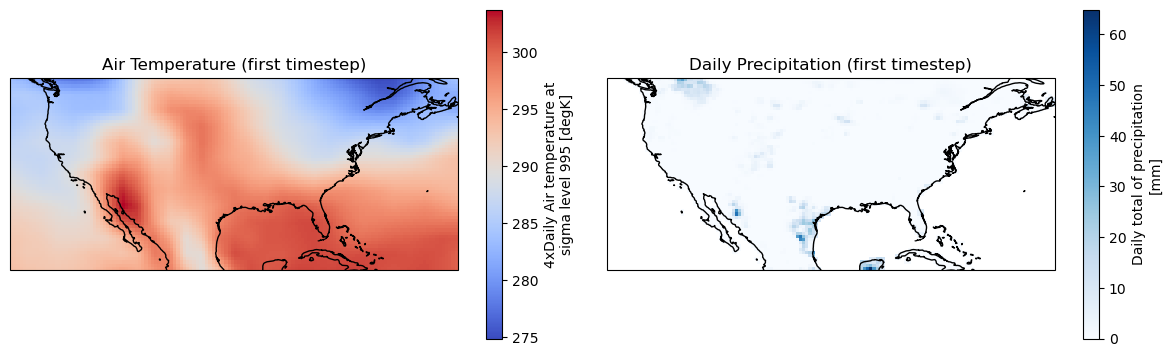

In [14]:
if ccrs is not None:
    proj = ccrs.PlateCarree()

    fig, axs = plt.subplots(1, 2, figsize=(12, 5),
                            subplot_kw={"projection": proj})

    # Plot air temperature at first timestep
    merged.air_temperature.isel(time=0).plot(
        ax=axs[0], transform=ccrs.PlateCarree(),
        cmap="coolwarm", cbar_kwargs={"shrink": 0.7}
    )
    axs[0].coastlines()
    axs[0].set_title("Air Temperature (first timestep)")

    # Plot daily precipitation at first timestep
    merged.daily_precip.isel(time=0).plot(
        ax=axs[1], transform=ccrs.PlateCarree(),
        cmap="Blues", cbar_kwargs={"shrink": 0.7}
    )
    axs[1].coastlines()
    axs[1].set_title("Daily Precipitation (first timestep)")

    plt.tight_layout()
    plt.show()

else:
    print("Cartopy not installed — skipping map plots.")

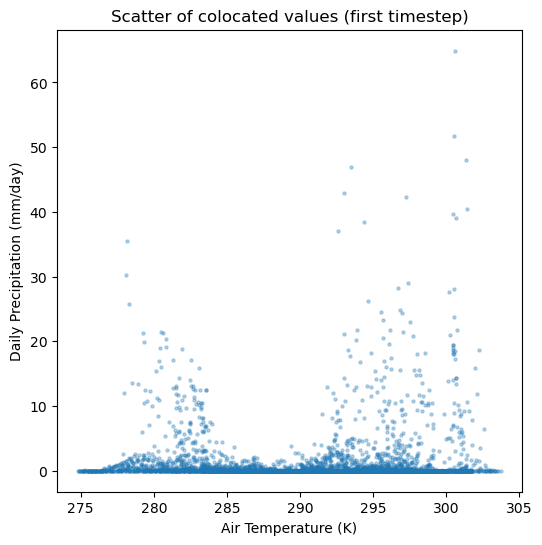

In [15]:
# Scatter plot comparing colocated values
plt.figure(figsize=(6, 6))
plt.scatter(
    merged.air_temperature.isel(time=0).values.ravel(),
    merged.daily_precip.isel(time=0).values.ravel(),
    alpha=0.3, s=5
)
plt.xlabel("Air Temperature (K)")
plt.ylabel("Daily Precipitation (mm/day)")
plt.title("Scatter of colocated values (first timestep)")
plt.show()

In [17]:
# Clear conflicting attributes to avoid NetCDF errors
merged.attrs = {}

# Also clear variable attributes if necessary
merged.air_temperature.attrs = {}
merged.daily_precip.attrs = {}

# Save to NetCDF
merged.to_netcdf("merged_air_precip_June2020.nc")
print("Merged dataset saved as merged_air_precip_June2020.nc")

Merged dataset saved as merged_air_precip_June2020.nc


In [20]:
# --- Reload check ---
check = xr.open_dataset('merged_air_precip_June2020.nc')
print("\nReloaded dataset:")
print(check)


Reloaded dataset:
<xarray.Dataset> Size: 2MB
Dimensions:          (time: 30, lat: 60, lon: 140)
Coordinates:
  * time             (time) datetime64[ns] 240B 2020-06-01 ... 2020-06-30
  * lat              (lat) float32 240B 49.75 49.25 48.75 ... 21.25 20.75 20.25
  * lon              (lon) float32 560B 230.2 230.8 231.2 ... 298.8 299.2 299.8
Data variables:
    air_temperature  (time, lat, lon) float32 1MB ...
    daily_precip     (time, lat, lon) float32 1MB ...


In [21]:
print("Original means:")
print("Tair:", float(merged.air_temperature.mean()))
print("Precip:", float(merged.daily_precip.mean()))

print("\nReloaded means:")
print("Tair:", float(check.air_temperature.mean()))
print("Precip:", float(check.daily_precip.mean()))

Original means:
Tair: 294.184326171875
Precip: 2.2267532348632812

Reloaded means:
Tair: 294.1842956542969
Precip: 2.2267532348632812
